# Activity: The Random Rollout Algorithm
In this activity, we will implement a simple version of the random rollout algorithm to solve a Markov decision process (MDP). The random rollout algorithm is a Monte Carlo method that estimates the value of each state by simulating random trajectories from that state and averaging the rewards received.

> __Learning Objectives:__
>
> By the end of this activity, you should be able to:
> Three learning objectives for this activity.
>

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Implementation
The utility function `U(...)` computes the utility of combinations of apples and oranges using a Cobb-Douglas utility model. A tuple holding the number of `(apples, oranges),` i.e., the combinations of objects we are searching over, and the $\alpha$-vector are passed as arguments; the `utility` value is returned.

In [2]:
function U(x::Tuple{Int,Int}, α::Array{Float64,1})::Float64
    
    # get the apples, and oranges 
    apples = x[1];
    oranges = x[2];
    
    # compute the objective -
    utility = (apples^α[1])*(oranges^α[2]);
    
    # return -
    return utility;
end;

## Task 1: Compute the optimal number of Apples and Oranges to purchase
Use a Cobb-Douglas utility function combined with a budget constraint to compute the optimal combination of apples and oranges that gives the maximum utility for the available budget. The Cobb-Douglas utility function for a collection of objects $x_{1},\cdots,x_{n}$ is given by:
$$
\begin{equation*}
U(x_{1},\cdots,x_{n}) = \prod_{i=1}^{n}x_{i}^{\alpha_{i}}
\end{equation*}
$$
where the $\alpha_{i}\geq{0}$ parameters are preference coefficents associated with each object. For this task, let's assume we have the following parameters:
* The preference coefficient vector $\alpha = (0.55,0.45)$ and the total budget is `50 USD`
* The unit price of an `apple` is `0.98 USD` and the unit price of an `orange` is `1.49 USD`
* Let `apples` be index `1` and `oranges` be index `2`
* Assume the bounds run from `0 to 100` and the initial guess is `0.1*ones(2)`.

### Strategy
* Use [the `build(...)` method](src/Factory.jl) to construct an instance of [the `MySimpleCobbDouglasChoiceProblem` type](src/Types.jl) holding the lecture parameters, and set this to the `base_problem` variable.
* Pass the `base_problem` problem to [the `solve(...)` function](src/Solve.jl), set the return to the variable `base_solution`.

In [3]:
true_solution, α, c, total_budget = let

    # initialize -
    α = [0.55, 0.45]; # coefficients
    c = [0.98, 1.49]; # price of x1 and x2
    total_budget = 50.0;

    # build my problem object -
    base = build(MySimpleCobbDouglasChoiceProblem, (
    
        initial = 0.1*ones(2), # initial guess
        α = α, # coefficients
        c = c, # price of x1 and x2
        I = total_budget, # income
    
        # how much of x₁ and x₂ can be we buy?
        bounds = [
            0.0 100.0; # L U
            0.0 100.0; # L U
        ]
    ));

    # call the solve function. This will return a dictionary -
    base_solution = solve(base);

    base_solution, α, c, total_budget; # return the solution
end;

This is MadNLP version v0.8.12, running with umfpack

Number of nonzeros in constraint Jacobian............:        2
Number of nonzeros in Lagrangian Hessian.............:        3

Total number of variables............................:        2
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        2
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        1
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1

iter    objective    inf_pr   inf_du inf_compl lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -1.0000000e-01 0.00e+00 4.71e-01 9.99e+01  -1.0 0.00e+00    -  0.00e+00 0.00e+00   0
   1 -2.4892203e-01 2.44e-15 3.46e-01 3.50e+01  -1.0 3.65e-

What is the __true__ optimal combination of apples and oranges?

In [4]:
optimal_apples = true_solution["argmax"][1] |> x-> round(x,digits=0) |> Int
optimal_oranges = true_solution["argmax"][2] |> x-> round(x,digits=0) |> Int
println("(apples, oranges) = ($(optimal_apples),$(optimal_oranges))")

(apples, oranges) = (28,15)


## Task 2: Solve the Apples and Oranges problem using Value Iteration

Let's start by setting up the apples and oranges world as a Markov decision process (MDP). Firt the world model.

We encoded the rectangular grid world using the `MyRectangularGridWorldModel` model, which we constructed using a `build(...)` method. Now, let's set up the data for the apples and oranges world, i.e., set up the states, actions, and rewards and then construct the world model. 

In [5]:
number_of_rows = 30
number_of_cols = 30
nactions = 4;
nstates = (number_of_rows*number_of_cols);
𝒮 = range(1,stop=nstates,step=1) |> collect;
𝒜 = range(1,stop=nactions,step=1) |> collect;
γ = 0.95;

Next, set up a description of the rewards, the `rewards::Dict{Tuple{Int,Int}, Float64}` dictionary, which maps the $(x,y)$-coordinates to a reward value. 

In [6]:
my_objective_value = U((optimal_apples, optimal_oranges), α)
rewards = Dict{Tuple{Int,Int}, Float64}()
rewards[(optimal_apples, optimal_oranges)] = my_objective_value;

# setup set of absorbing states -
absorbing_state_set = Set{Tuple{Int,Int}}()
push!(absorbing_state_set, (optimal_apples, optimal_oranges));

Finally, build an instance of the `MyRectangularGridWorldModel` type, which models the grid world. 

Pass in the number of rows `nrows,` number of cols `ncols,` and our initial reward description in the `rewards` field into [the `build(...)` method](src/Factory.jl). Save the world model instance to the `world::MyRectangularGridWorldModel` variable

In [7]:
world = build(MyRectangularGridWorldModel, 
    (nrows = number_of_rows, ncols = number_of_cols, rewards = rewards));


#### Rewards $R(s,a)$
We'll encode the reward function as a $\dim\mathcal{S}\times\dim\mathcal{A}$ array, which holds the reward values for being in state $s\in\mathcal{S}$ and taking action $a\in\mathcal{A}$. After initializing the reward `R::Array{Float64,2}` array with zeros, populate the non-zero values of $R(s, a)$ using a nested [for loop](https://docs.julialang.org/en/v1/base/base/#for). During each outer loop iteration, we select a state $s\in\mathcal{S}$ and the inner loop iterates over actions $a\in\mathcal{A}$.

Given a Select a state `s,` an action `a`, and a move $\Delta$:
* Compute the new position resulting from implementing action `a` and store this in the `new_position` variable. If the `new_position`$\in\mathcal{S}$ is in our initial `rewards` dictionary, we use that reward value. If we are still in the world but not in a special location, we set the reward to `-1`. If `new_position`$\notin\mathcal{S}$, i.e., the `new_position` is a space outside the grid, we set a penalty of `-50000.0`.

In [8]:
R, soft_wall_set = let

    R = zeros(nstates, nactions);
    fill!(R, 0.0)
    for s ∈ 𝒮
        for a ∈ 𝒜
            
            Δ = world.moves[a];
            current_position = world.coordinates[s]
            new_position =  current_position .+ Δ
            
            if (haskey(world.states, new_position) == true)
                if (haskey(rewards, new_position) == true)
                    R[s,a] = rewards[new_position];
                else
                    R[s,a] = U(new_position, α);
                end
            else
                R[s,a] = -50000.0; # we are off the grid, big negative penalty
            end
        end
    end

    # setup soft walls -
    soft_wall_set = Set{Tuple{Int,Int}}();
    for s ∈ 𝒮
        
        # get the position -
        current_position = world.coordinates[s]
        
        # does this position violate the budget?
        budget_violation = max(0.0, c[1]*current_position[1]+c[2]*current_position[2] - total_budget)
        if (budget_violation ≥ 1.0)
            push!(soft_wall_set, current_position)
        end
    end

    for s ∈ 𝒮
        current_position = world.coordinates[s]
        for a ∈ 𝒜
            Δ = world.moves[a];
            new_position =  current_position .+ Δ
            
            if (in(new_position, soft_wall_set) == true)
            R[s,a] = -1000.0  
            end
        end
    end
    R, soft_wall_set # return
end

([-50000.0 1.4640856959456254 -50000.0 1.3660402567543954; -50000.0 2.0 1.0 1.639474116758873; … ; -1000.0 -50000.0 -1000.0 -1000.0; -1000.0 -50000.0 -1000.0 -50000.0], Set([(23, 27), (22, 28), (29, 19), (25, 18), (25, 24), (15, 29), (27, 26), (27, 17), (26, 27), (18, 24)  …  (29, 29), (14, 30), (28, 16), (23, 20), (13, 26), (17, 29), (28, 18), (12, 27), (26, 20), (28, 24)]))

#### Transition $T(s, s^{\prime},a)$
Next, build the transition function $T(s,s^{\prime},a)$. We'll encode this as a $\dim\mathcal{S}\times\dim\mathcal{S}\times\dim\mathcal{A}$ [multidimension array](https://docs.julialang.org/en/v1/manual/arrays/) and populate it using nested `for` loops. I've already done this, so back away slowly and move on to the next task.
* The `outer` loop we will iterate over actions. For every $a\in\mathcal{A}$ will get the move associated with that action and store it in the `Δ::Tuple.`
* In the `inner` loop, we will iterate over states $s\in\mathcal{S}$. We compute a `new_position` resulting from implementing action $a$ and check if `new_position`$\in\mathcal{S}$. If `new_position` is in the world, and `current_position` is _not_ an `absorbing state` we set $s^{\prime}\leftarrow$`world.states[new_position]`, and `T[s, s′,  a] = 1.0`
* However, if the `new_position` is outside of the grid (or we are jumping from an `absorbing` state), we set `T[s, s,  a] = 1.0`, i.e., the probability that we stay in `s` if we take action `a` is `1.0`.

In [9]:
T = let
    T = Array{Float64,3}(undef, nstates, nstates, nactions);
    fill!(T, 0.0)
    
    for a ∈ 𝒜
    
        Δ = world.moves[a];
    
        for s ∈ 𝒮
            current_position = world.coordinates[s]
            new_position =  current_position .+ Δ
            if (haskey(world.states, new_position) == true && 
                in(current_position, absorbing_state_set) == false)
                s′ = world.states[new_position];
                T[s, s′,  a] = 1.0
            else
                T[s, s,  a] = 1.0
            end
        end
    end
    T;
end

900×900×4 Array{Float64, 3}:
[:, :, 1] =
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ⋮                        ⋮              ⋱            ⋮                   
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  

Construct a Markov Decision Process (MDP) instance and solve the problem using value iteration. The solution of the value iteration procedure is then used to estimate the optimal policy $\pi^{\star}(s)$. Toward this task:

Construct an instance of the `MyMDPProblemModel,` which encodes the data required to solve the MDP problem. Pass the states `𝒮,` the actions `𝒜,` the transition matrix `T,` the reward matrix `R,` and the discount factor `γ` into [the `build(...)` method](src/Factory.jl). We store the MDP model in the `m::MyMDPProblemModel` variable:

In [10]:
m = build(MyMDPProblemModel, (𝒮 = 𝒮, 𝒜 = 𝒜, T = T, R = R, γ = γ));

Next, call [the `solve(...)` method](src/Solve.jl) by passing a `value_iteration_model` instance and our MDP model `m::MyMDPProblemModel` as arguments. [The `solve(...)` method](src/Solve.jl) iteratively computes the optimal value function $U^{\star}(s)$ and returns it in an instance of the `MyValueFunctionPolicy` type.

In [11]:
value_iteration_solution = let

    k_max = 250; # maximum number of iterations
    value_iteration_model = MyValueIterationModel(k_max); # takes k_max as argument
    solution = solve(value_iteration_model,m);
    
    # solution -
    solution
end;

Now, we extract the action-value function $Q(s, a)$ from the optimal optimal value function $U^{\star}(s)$. We can do this using [the `Q(...)` function](src/Compute.jl), which takes `m::MyMDPProblemModel` and the `solution::MyValueFunctionPolicy.` Save the optimal $Q(s,a)$ in the `my_Q::Array{Float64,2}` variable:

In [12]:
my_Q = Q(m, value_iteration_solution.U)

900×4 Matrix{Float64}:
 -49813.8      196.021  -49813.8       195.923
 -49805.4      204.797     187.22      204.342
 -49797.3      213.372     195.923     212.493
 -49789.4      221.712     204.342     220.381
 -49781.7      229.808     212.493     227.998
 -49774.2      237.64      220.381     235.35
 -49767.1      245.21      227.998     242.442
 -49760.1      252.519     235.35      249.278
 -49753.4      259.568     242.442     255.856
 -49747.0      266.355     249.278     262.175
      ⋮                             
  -5732.47  -55445.8     -5732.47    -7123.55
  -6445.84  -56123.6     -6445.84    -7767.37
  -7123.55  -56767.4     -7123.55    -8379.01
  -7767.37  -57379.0     -7767.37    -8960.06
  -8379.01  -57960.1     -8379.01    -9512.05
  -8960.06  -58512.1     -8960.06   -10036.4
  -9512.05  -59036.4     -9512.05   -10534.6
 -10036.4   -59534.6    -10036.4    -11007.9
 -10534.6   -60007.9    -10534.6    -60007.9

Finally, compute the optimal navigation policy $\pi^{\star}(s)$ from $Q(s,a)$ using [the `policy(...)` function](src/Compute.jl). Save this in the `my_π::Array{Int64,1}` variable:

In [13]:
my_π = policy(my_Q)

900-element Vector{Int64}:
 2
 2
 2
 2
 2
 2
 2
 2
 2
 2
 ⋮
 1
 1
 1
 1
 1
 1
 1
 1
 1

### Visualize the optimal policy
`Unhide` the code block below to see how we visualize the decision maker's path through the apples versus oranges space to arrive at the optimal solution. 

Specify an initial starting tuple `(apples,oranges)` in the `initial_site` variable:`

In [14]:
initial_site = (1,10); # horizontal, vertical

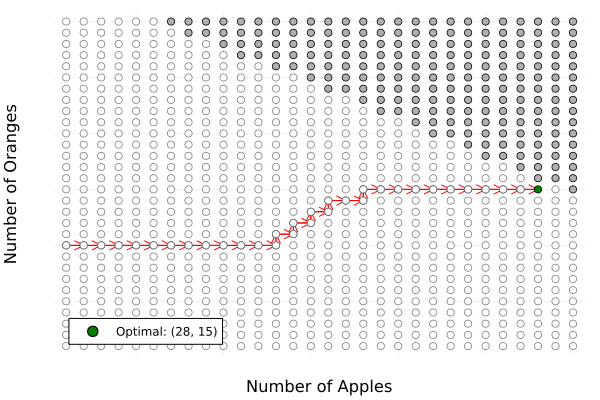

In [15]:
let
    # draw the path -
    p = plot();
    hit_absorbing_state = false
    s = world.states[initial_site];
    visited_sites = Set{Tuple{Int,Int}}();
    push!(visited_sites, initial_site);
    
    while (hit_absorbing_state == false)
        current_position = world.coordinates[s]
        a = my_π[s];
        Δ = world.moves[a];
        new_position =  current_position .+ Δ
        scatter!([current_position[1]],[current_position[2]], label="", showaxis=:false, msc=:black, c=:blue)
        plot!([current_position[1], new_position[1]],[current_position[2], new_position[2]], label="", arrow=true, lw=1, c=:red)
        
        if (in(new_position, absorbing_state_set) == true || in(new_position, visited_sites) == true)
            hit_absorbing_state = true;
        else
            s = world.states[new_position];
            push!(visited_sites, new_position);
        end
    end
    
    # draw the grid -
    for s ∈ 𝒮
        current_position = world.coordinates[s]
        a = my_π[s];
        Δ = world.moves[a];
        new_position =  current_position .+ Δ
        
        if (haskey(rewards, current_position) == true && rewards[current_position] == my_objective_value)
            scatter!([current_position[1]],[current_position[2]], label="Optimal: $(current_position)", c=:green, ms=4, legend=:bottomleft)
        elseif (in(current_position, soft_wall_set) == true)
            scatter!([current_position[1]],[current_position[2]], label="", showaxis=:false, c=:gray69, ms=4)
        else
            scatter!([current_position[1]],[current_position[2]], label="", showaxis=:false, msc=:gray50, c=:white)
        end
    end
    xlabel!("Number of Apples",fontsize=18)
    ylabel!("Number of Oranges",fontsize=18)
    current()
end

## Task 3: Solve the Apples and Oranges problem using Random Rollout
In this task, we will implement the random rollout algorithm to solve the apples and oranges problem. The random rollout algorithm estimates the value of each state by simulating random trajectories from that state and averaging the rewards received.

First, let's set the `depth` that are going to explore, i.e., how many steps are we going to take when exploring each state `s`. We'll warp this in the `MyRandomRollout` type

In [16]:
d = 200;
random_rollout_model = MyRandomRolloutModel(d);

We use a for loop to compute the value (utility) starting from each state in the system. For each state $s\in\mathcal{S}$, we call the `myrollout(...)` function, which explores the system to a depth `d`, returns the value (utility) at state `s,` and saves the value in the `utility_array::Array{Float64,1}`.

In [17]:
utility_array = Array{Float64,1}();
for s ∈ 𝒮

    value =  solve(random_rollout_model,m,world,s);
    push!(utility_array, value)
end

Extract the `action-value function` or $Q(s, a)$ from the `utility_array`. We can do this using the `Q(...)` function, which takes `m` and the `utility_array`:

In [18]:
my_Q_random_rollout = Q(m, utility_array);

Finally, we can extract the policy $\pi(s)$ from the action-value function $Q(s,a)$ using the `policy(...)` function:

In [19]:
my_π_random_rollout = policy(my_Q_random_rollout);

### Visualize
`Unhide` the code block below to see how we plot the path from a `startstate` to (potentially) one of the absorbing states. The charging station is show in green, while the lava pits are shown in red. Specify the `startstate` coordinate tuple:

In [22]:
random_rollout_startstate = (28,7);

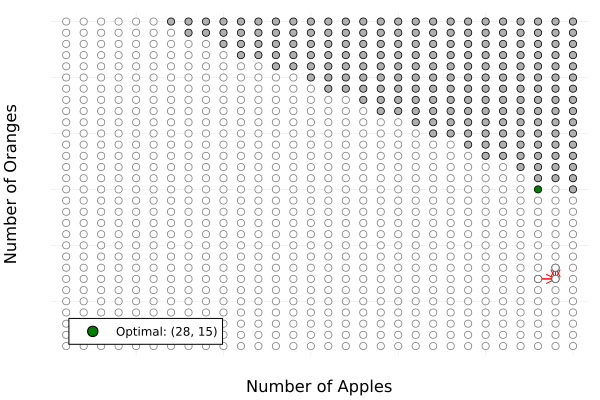

In [23]:
let
    # draw the path -
    p = plot();
    hit_absorbing_state = false
    initial_site = random_rollout_startstate;
    s = world.states[initial_site];
    visited_sites = Set{Tuple{Int,Int}}();
    push!(visited_sites, initial_site);
    my_π = my_π_random_rollout;
    
    while (hit_absorbing_state == false)
        current_position = world.coordinates[s]
        a = my_π[s];
        Δ = world.moves[a];
        new_position =  current_position .+ Δ
        scatter!([current_position[1]],[current_position[2]], label="", showaxis=:false, msc=:black, c=:blue)
        plot!([current_position[1], new_position[1]],[current_position[2], new_position[2]], label="", arrow=true, lw=1, c=:red)
        
        if (in(new_position, absorbing_state_set) == true || in(new_position, visited_sites) == true)
            hit_absorbing_state = true;
        else
            s = world.states[new_position];
            push!(visited_sites, new_position);
        end
    end
    
    # draw the grid -
    for s ∈ 𝒮
        current_position = world.coordinates[s]
        a = my_π[s];
        Δ = world.moves[a];
        new_position =  current_position .+ Δ
        
        if (haskey(rewards, current_position) == true && rewards[current_position] == my_objective_value)
            scatter!([current_position[1]],[current_position[2]], label="Optimal: $(current_position)", c=:green, ms=4, legend=:bottomleft)
        elseif (in(current_position, soft_wall_set) == true)
            scatter!([current_position[1]],[current_position[2]], label="", showaxis=:false, c=:gray69, ms=4)
        else
            scatter!([current_position[1]],[current_position[2]], label="", showaxis=:false, msc=:gray50, c=:white)
        end
    end
    xlabel!("Number of Apples",fontsize=18)
    ylabel!("Number of Oranges",fontsize=18)
    current()
end

## Summary
One summary sentence about the activity here. 

> __Key Takeaways:__
> 
> Three key takeaways from this activity.

One conclusion sentence about the activity here.
___